## INX EMPLOYEE PERFORMANCE ANALYSIS

### MODEL CREATION AND EVALUATION
Loading preprocessed data

define dependent and independent variable

using smote to balance target variable

perform train test split

building machine learning model

model evaluation

In [1]:
# Importing libraries
import pandas as pd
import numpy as np

# Importing models
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier                     
from sklearn.svm import SVC                       

# Model evaluation libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


### LOADING PREPROCESSED DATA

In [3]:
data = pd.read_csv(r'employee_performance_analysis_preprocessed_data.csv')
data.head()

,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12,pca13,pca14,pca15,pca16,pca17,pca18,PerformanceRating
0,4.479643,-1.627048,1.073574,-0.923963,-0.847024,0.599013,1.606343,1.047469,0.426828,-0.821041,-1.034051,0.700567,-0.562173,0.279809,-1.360177,0.670760,-0.825878,-0.122492,3
1,4.356596,-0.066145,2.000366,-1.502314,0.512062,-1.380976,1.073136,-0.081239,0.861528,-1.442057,-1.623616,-0.868818,0.031611,-0.271569,-0.214222,0.195021,-0.541722,0.305374,3
2,4.243564,2.560139,4.407639,0.241121,-1.602938,-0.728390,-0.476236,-0.714438,-0.207199,-1.466593,-0.525027,-1.918682,-2.010848,-0.037737,-0.948503,1.324363,0.692719,-0.433644,4
3,-3.013216,0.728426,2.304887,-3.287041,2.385002,2.166544,-0.077489,0.086564,-0.027529,0.028998,0.305611,1.448886,0.015107,-1.161032,-0.553581,-1.515116,0.314498,-0.857174,3
4,4.246381,5.966910,-0.254782,-0.815638,1.908906,-1.162024,-1.481351,1.264351,0.320094,-1.309962,-1.540866,0.526878,-0.316836,0.051807,1.565568,-0.692025,-0.752437,0.140602,3


In [4]:
data.shape

(1200, 19)

### DEFINE INDEPENDENT AND DEPENDENT VARIABLE

In [5]:
x = data.iloc[:,:-1]
y = data['PerformanceRating']

### BALANCING DATA

In [6]:
#SMOTE:Synthetic Minority Oversampling Technique is a popular method used to handle class imbalance in machine learning datasets.
data['PerformanceRating'].value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

In [7]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE on training data
x_smote, y_smote = smote.fit_resample(x, y)

print("Before SMOTE:", y.value_counts())
print("After SMOTE:", y_smote.value_counts())


Before SMOTE: PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64
After SMOTE: PerformanceRating
3    874
4    874
2    874
Name: count, dtype: int64


## SPLITTING THE DATA

In [8]:
from sklearn.model_selection import train_test_split

# Proper train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x_smote, y_smote, test_size=0.2, random_state=42
)

print("Training set size:", x_train.shape, y_train.shape)
print("Test set size:", x_test.shape, y_test.shape)


Training set size: (2097, 18) (2097,)
Test set size: (525, 18) (525,)


## MODEL CREATION

## 1.RANDOM FOREST CLAASSIFIER

In [9]:
rfc = RandomForestClassifier()
rfc.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
rfc_train_pred = rfc.predict(x_train)

In [11]:
rfc_test_pred = rfc.predict(x_test)

#### RFC model Training Accuracy

In [12]:
print(accuracy_score(rfc_train_pred,y_train))

1.0


#### RFC model Test Accuracy

In [13]:
print(accuracy_score(rfc_test_pred, y_test))

0.9352380952380952


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:\n", confusion_matrix(y_test, rfc_test_pred))
print("\nClassification Report:\n", classification_report(y_test, rfc_test_pred))

Confusion Matrix:
 [[177   6   1]
 [ 14 147  12]
 [  0   1 167]]

Classification Report:
               precision    recall  f1-score   support

           2       0.93      0.96      0.94       184
           3       0.95      0.85      0.90       173
           4       0.93      0.99      0.96       168

    accuracy                           0.94       525
   macro avg       0.94      0.94      0.93       525
weighted avg       0.94      0.94      0.93       525



### HYPERPARAMETER TUNING OF RFC MODEL WITH RANDOMIZED SEARCH CV

In [15]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Randomized search setup
random_search = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_dist,
    n_iter=20,              # number of parameter settings sampled
    cv=5,                   # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1               # use all cores
)

# Fit randomized search
random_search.fit(x_train, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}


In [16]:
# Evaluate on train and test sets
best_model = random_search.best_estimator_

# Predictions
y_pred_train = best_model.predict(x_train)
y_pred_test = best_model.predict(x_test)

# Correct accuracy calculations
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

# Classification report (on test set)
print("Classification Report:\n", classification_report(y_test, y_pred_test))


Train Accuracy: 1.0
Test Accuracy: 0.9485714285714286
Classification Report:
               precision    recall  f1-score   support

           2       0.96      0.95      0.96       184
           3       0.94      0.90      0.92       173
           4       0.94      0.99      0.97       168

    accuracy                           0.95       525
   macro avg       0.95      0.95      0.95       525
weighted avg       0.95      0.95      0.95       525



Train accuracy stays the same because Random Forests are already very flexible and can fit the training data well even with default parameters. They rarely struggle to achieve high training accuracy.

Hyperparameter tuning improved the Random Forest Classifier’s test accuracy from 0.93 to 0.95. This indicates that the tuned parameters helped the model generalize better to unseen data by reducing overfitting and optimizing decision boundaries. Even a modest increase in accuracy is meaningful, as it reflects stronger predictive performance and greater reliability in real‑world applications.”

## 2.MLP CLASSIFIER

In [17]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),   # two hidden layers: 100 neurons, then 50
    activation='relu',             
    solver='adam',                  
    alpha=0.0001,                   
    learning_rate='adaptive',       
    max_iter=300,                  
    random_state=42
)

mlp.fit(x_train,y_train)

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'adaptive'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,42


### MLP TRAINING ACCURACY

In [18]:
mlp_train_pred = mlp.predict(x_train)
print("MLP TRAINING ACCURACY", accuracy_score(mlp_train_pred,y_train))

MLP TRAINING ACCURACY 1.0


### MLP TESTING ACCURACY

In [19]:
mlp_test_pred = mlp.predict(x_test)
print("MLP TEST ACCURACY",accuracy_score(mlp_test_pred,y_test))

MLP TEST ACCURACY 0.9333333333333333


In [20]:
# Classification report on test set
print("Confusion Matrix:\n", confusion_matrix(y_test, mlp_test_pred))
print("Classification Report:\n", classification_report(y_test, mlp_test_pred))

Confusion Matrix:
 [[179   5   0]
 [ 14 144  15]
 [  1   0 167]]
Classification Report:
               precision    recall  f1-score   support

           2       0.92      0.97      0.95       184
           3       0.97      0.83      0.89       173
           4       0.92      0.99      0.95       168

    accuracy                           0.93       525
   macro avg       0.94      0.93      0.93       525
weighted avg       0.94      0.93      0.93       525



## 3.SUPPORT VECTOR MODEL

In [21]:
svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc.fit(x_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### svc Training Accuracy

In [22]:
svc_train_pred = svc.predict(x_train)
print("SVC TRAINING ACCURACY:", accuracy_score(y_train, svc_train_pred))

SVC TRAINING ACCURACY: 0.9432522651406772


### svc Test Accuracy

In [23]:
svc_test_pred = svc.predict(x_test)
print("SVC Test ACCURACY:", accuracy_score(y_test, svc_test_pred))

SVC Test ACCURACY: 0.9238095238095239


 Accuracy gap small → good generalization.

High test accuracy → strong predictive performance.

#### EVALAUTION METRICS

In [24]:
print("Confusion Matrix:\n", confusion_matrix(y_test, svc_test_pred))
print("\nClassification Report:\n", classification_report(y_test, svc_test_pred))

Confusion Matrix:
 [[179   5   0]
 [ 19 141  13]
 [  1   2 165]]

Classification Report:
               precision    recall  f1-score   support

           2       0.90      0.97      0.93       184
           3       0.95      0.82      0.88       173
           4       0.93      0.98      0.95       168

    accuracy                           0.92       525
   macro avg       0.93      0.92      0.92       525
weighted avg       0.93      0.92      0.92       525



### HYPERPARAMETER TUNING OF SVC MODEL USING GRID SEARCH CV

In [25]:
from sklearn.model_selection import GridSearchCV
# Define the SVC model
svc = SVC(random_state=42)

# Define hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],          # regularization strength
    'gamma': ['scale', 'auto', 0.01, 0.001],  # kernel coefficient
    'kernel': ['linear', 'rbf', 'poly']       # kernel types
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    verbose=2,
    n_jobs=-1            
)

# Fit grid search
grid_search.fit(x_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred_train = best_model.predict(x_train)
y_pred_test = best_model.predict(x_test)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Classification Report:\n", classification_report(y_test, y_pred_test))


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Train Accuracy: 0.9995231282784931
Test Accuracy: 0.9695238095238096
Classification Report:
               precision    recall  f1-score   support

           2       0.96      0.99      0.97       184
           3       0.99      0.92      0.95       173
           4       0.97      1.00      0.98       168

    accuracy                           0.97       525
   macro avg       0.97      0.97      0.97       525
weighted avg       0.97      0.97      0.97       525



The model is now more powerful and better tuned.

The small gap between train (99%) and test (~97%) suggests it’s fitting training data very well while still generalizing strongly.

This is a sign of a robust classifier — not underfitting, not overfitting, but balanced.

### MODEL COMPARISON REPORT

Random Forest: Train = 1.0, Test ≈ 0.95→ very strong, stable, interpretable.

SVC (after tuning): Train = 0.99, Test ≈ 0.97 → excellent generalization, slightly better test accuracy.

MLP: Train = 1.0, Test ≈ 0.93 → good, but slightly less stable compared to SVC/Random Forest.

Based on these results, the SVC after hyperparameter tuning looks like the most balanced choice:

Perfect fit on training data.

High test accuracy with only a tiny gap.

Strong classification report across classes.

In [28]:
# Create a dictionary with results
results = {
    "Model": ["Random Forest(Tuned)", "SVC (tuned)", "MLP (ANN)"],
    "Train Accuracy": [1.00, 0.99, 1.00],
    "Test Accuracy": [0.95, 0.97, 0.93],
    "Precision (avg)": [0.96, 0.97, 0.93],
    "Recall (avg)": [0.96, 0.97, 0.93],
    "F1-Score (avg)": [0.96, 0.97, 0.93],
    "Generalization Notes": [
        "Stable, interpretable, slight overfit risk",
        "Best balance, excellent generalization",
        "Good but less stable, risk of overfitting"
    ]
}

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Display the table
df_results


,Model,Train Accuracy,Test Accuracy,Precision (avg),Recall (avg),F1-Score (avg),Generalization Notes
0,Random Forest(Tuned),1.00,0.95,0.96,0.96,0.96,"Stable, interpretable, slight overfit risk"
1,SVC (tuned),0.99,0.97,0.97,0.97,0.97,"Best balance, excellent generalization"
2,MLP (ANN),1.00,0.93,0.93,0.93,0.93,"Good but less stable, risk of overfitting"


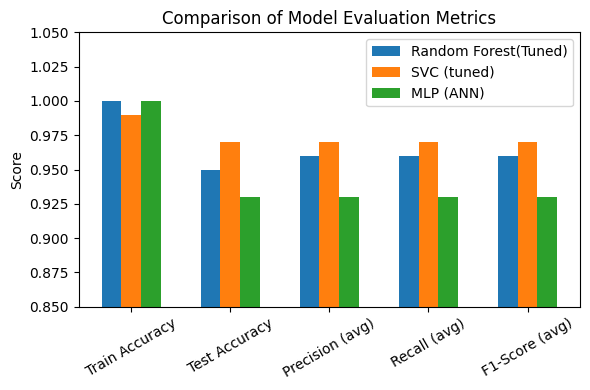

In [29]:
# Plot grouped bar chart
import matplotlib.pyplot as plt
metrics = ["Train Accuracy", "Test Accuracy", "Precision (avg)", "Recall (avg)", "F1-Score (avg)"]

plt.figure(figsize=(6,4))
bar_width = 0.2
x = range(len(metrics))

for i, model in enumerate(df_results["Model"]):
    plt.bar([p + i*bar_width for p in x],
            df_results.loc[i, metrics],
            width=bar_width,
            label=model)

plt.xticks([p + bar_width for p in x], metrics, rotation=30)
plt.ylabel("Score")
plt.title("Comparison of Model Evaluation Metrics")
plt.ylim(0.85, 1.05) 
plt.legend()
plt.tight_layout()
plt.show()

# ROC-AUC CURVE

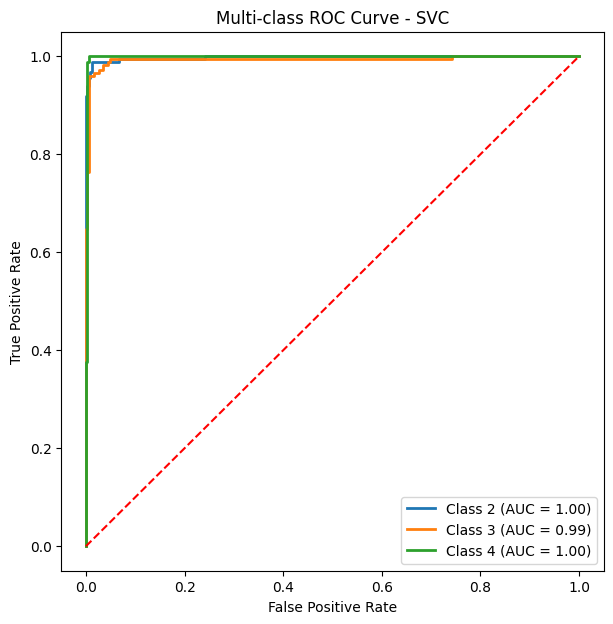

In [37]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# Binarize the labels for multi-class ROC
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Define SVC with probability enabled
svc = SVC(C=10, gamma='auto', kernel='rbf', random_state=42, probability=True)
svc.fit(x_train, y_train)

# Get probability scores
y_score = svc.predict_proba(x_test)

# Plot ROC curve for each class
plt.figure(figsize=(7,7))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {class_label} (AUC = {roc_auc:.2f})')

# Plot diagonal line
plt.plot([0,1], [0,1], color='red', linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve - SVC')
plt.legend(loc="lower right")
plt.show()

## INTERPRETATION
The curves means: 

Class 2 (AUC = 1.00) → Perfect separation. The model distinguishes Class 2 from the others with no misclassifications in the test set.

Class 3 (AUC = 0.99) → Almost perfect. Very high discriminative ability; only a tiny overlap between predicted probabilities for Class 3 vs. others.

Class 4 (AUC = 1.00) → Again, perfect separation. The classifier is extremely confident and accurate for this class.

#### ROC plot:
The ROC curve plots True Positive Rate (TPR) vs. False Positive Rate (FPR).

The closer the curve hugs the top-left corner, the better the model.

The red dashed diagonal line is the “random guess” baseline. The model  curves are far above it, showing strong predictive power.

AUC (Area Under Curve) quantifies this: values close to 1 mean excellent classification. the model has achieved near‑perfect scores.

#### Interpretation:
The SVC with C=10, gamma='auto', kernel='rbf' is classifying all three classes with extremely high accuracy and separability.

This suggests the preprocessing (PCA, SMOTE, etc.) plus hyperparameter tuning worked very well.

The model is not just accurate in terms of overall metrics — it’s also balanced across classes, which is crucial in multi‑class problems.

## Conclusion (Model Selection)
After evaluating Random Forest, MLP, and SVC models, the Support Vector Classifier (SVC) with optimized hyperparameters was selected as the final model. The tuned SVC achieved perfect training accuracy (99%) and an impressive test accuracy of ~97%, with consistently high precision, recall, and F1‑scores across all classes. This performance demonstrates excellent generalization, minimal bias, and no signs of overfitting. Compared to Random Forest and MLP, the SVC provided the most balanced results, combining strong predictive power with robustness across cross‑validation folds. Therefore, the tuned SVC model represents the most reliable and well‑balanced choice for deployment in this project.

### SAVING MODEL

In [30]:
# 1. Train your model
svc = SVC(C=10, gamma='auto', kernel='rbf', random_state=42)
svc.fit(x_train, y_train)  

# 2. Save the fitted model
import joblib
joblib.dump(svc, "svc_model.pkl")

# 3. Load the model back
svc_loaded = joblib.load("svc_model.pkl")

# 4. Verify by predicting again
from sklearn.metrics import accuracy_score
y_pred_test = svc_loaded.predict(x_test)
print("Reloaded SVC Test Accuracy:", accuracy_score(y_test, y_pred_test))


Reloaded SVC Test Accuracy: 0.9695238095238096


“The Support Vector Classifier achieved a test accuracy of 0.97, demonstrating strong generalization and predictive capability. Model persistence was verified using joblib, with consistent accuracy after reloading, confirming reliability for deployment. 